In [22]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
data = r"C:\Users\Noman khan\Downloads\archive (7)\train.csv"
df = pd.read_csv(data)
print(df.head())
print(df.info())
print(df.describe())
print(df.columns)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [ ]:
print(df.isnull().sum())

print(df.select_dtypes(include=object).columns.tolist())
print(df.select_dtypes(include=float).columns.tolist())
print(df.select_dtypes(include=int).columns.tolist())
 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
['Age', 'Fare']
['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch']
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[891 rows x 0 columns]


## Data Story
I download titanic dataset from kaggle, and load it by using pd.read_csv method. I discovered in the dataset that it has 891 rows, 12 columns. Out of 12 columns 5 is a object, 5 is a int type columns and 2 is a float columns. By using df.isnull().sum(), i discovered that cabin column has 687 missing values, age has 177 missing values and Ebarked has only 2 missing values . I also apply describe() method which gives the statistical summary.


In [21]:
print(df["Embarked"].head())

df["Age"] = df['Age'].fillna(df["Age"].mean())
df["Embarked"] = df['Embarked'].fillna(df["Embarked"].mode()[0])
df = df.drop('Cabin', axis=1, errors="ignore")

print(df.columns)
print(df["Embarked"].isnull().sum())

1     C
3     S
6     S
10    S
11    S
Name: Embarked, dtype: object
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
0


## Why i used Fillna() and drop?
I used fillna() on 'Age' and "Embarked" which had 177 and 2 missing values respectively. Beacuase age column is a int column which has only  177 missnig values so droping this column would be wrong so i filled it by mean() methd and Embarked has only 2 and it is a object column so i filled it by mode method. Object is column is filled with most repeated value that is why i used mode. And Cabin column has dropped because it has many missing values. So droping it is not bad choice.                    

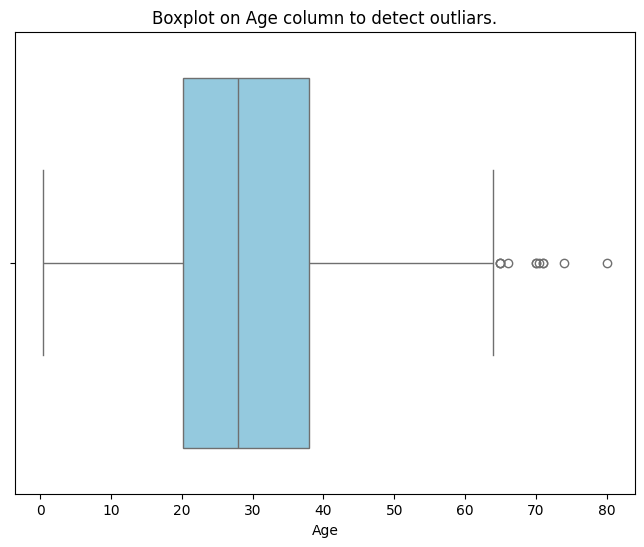

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["Age"], color="skyblue")
plt.title("Boxplot on Age column to detect outliars.")
plt.xlabel("Age")
plt.show()

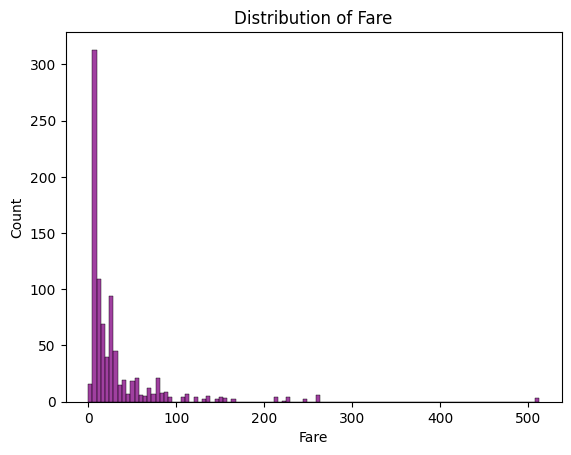

In [34]:
sns.histplot(df["Fare"], color="purple")
plt.title("Distribution of Fare")
plt.show()


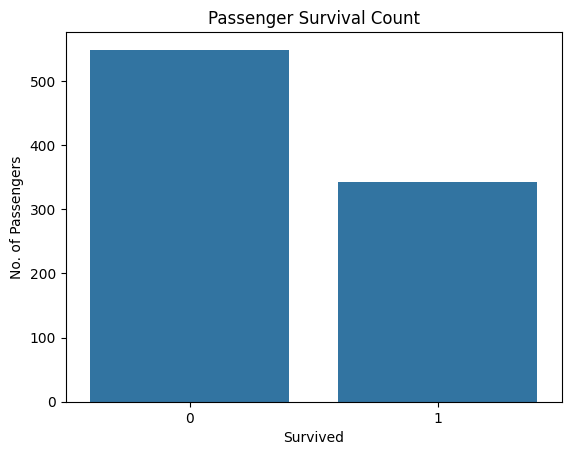

In [37]:
sns.countplot(x="Survived", data=df)
plt.title("Passenger Survival Count")
plt.ylabel("No. of Passengers")  
plt.show()

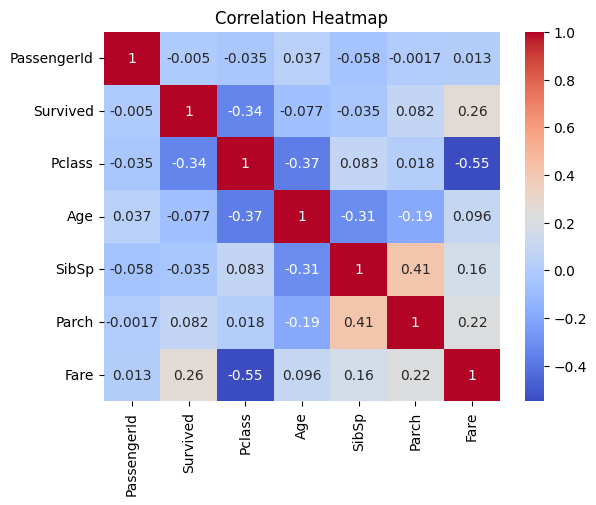

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Finding
Based on the heatmap, Pclass has the strongest relationship with Survival(-0.34). This means passeners in higher classes(1st class) were more likely to survive than those in lower classes. 